In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import RocCurveDisplay

%matplotlib inline

In [116]:
#read the dataset in
df = pd.read_csv('Pumpkin_Seeds_Dataset.csv',encoding='utf-8')

In [119]:
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,0
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,0
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,0
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,0
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,0


In [120]:
#encode class column from categorical data to numbers 
df['Class'] = LabelEncoder().fit_transform(df['Class'])

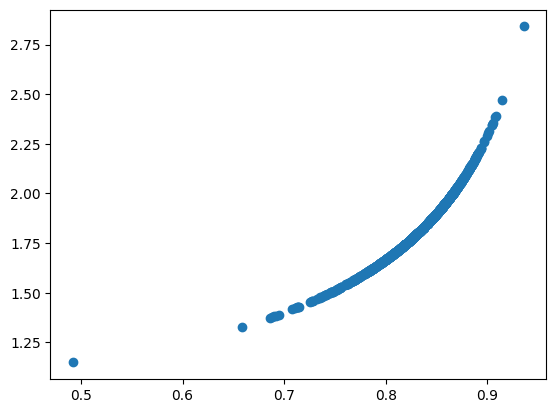

In [121]:
#scatter plot for Çerçevelik class of pumpkin seeds
x = df.iloc[0:1299,6]
y = df.iloc[0:1299,10]
plt.scatter(x,y)



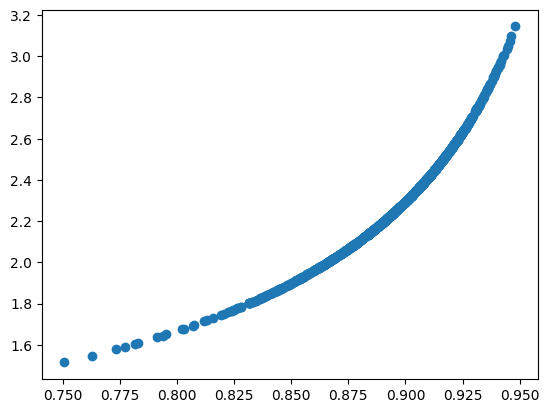

In [122]:
#scatter plot for Ürgüp Sivrisi class of pumpkin seeds
x = df.iloc[1300:2500,6]
y = df.iloc[1300:2500,10]
plt.scatter(x,y)



In [123]:
#make x the data and y the target
x = df.iloc[0:,:-1].values
y = df.iloc[0:, -1].values

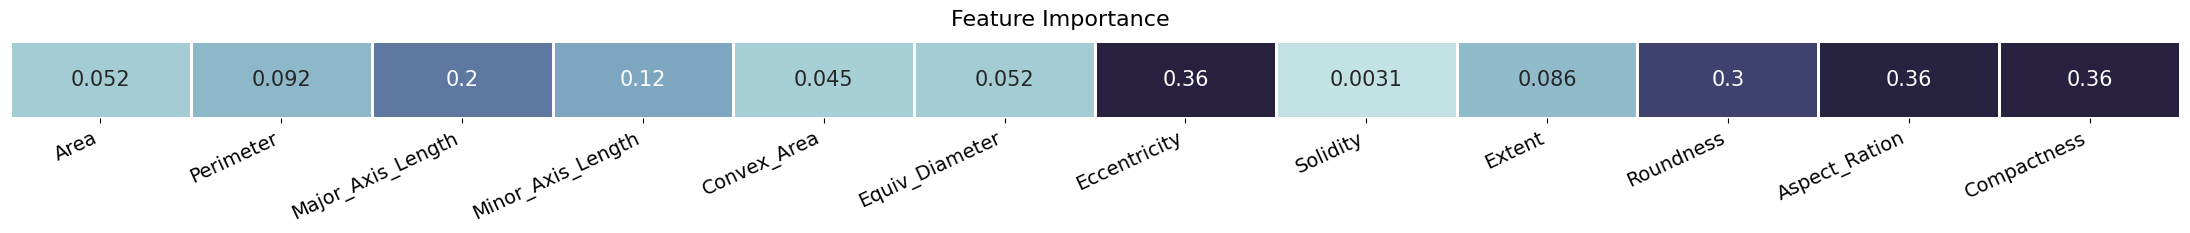

In [124]:
# Feature selection
mutual_information = mutual_info_classif(x, y, n_neighbors=5, copy = True)

columns = df.drop('Class',axis=1)
plt.subplots(1, figsize=(28, 1))
sns.color_palette("Set2")
sns.heatmap(mutual_information[:, np.newaxis].T, cmap=sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True), cbar=False, linewidths=1, annot=True, annot_kws={"size": 15})
plt.yticks([], [])
plt.gca().set_xticklabels(columns, rotation=25, ha='right', fontsize=14)
plt.suptitle("Feature Importance", fontsize=16, y=1.2)
plt.gcf().subplots_adjust(wspace=0.4)

In [125]:
#most important features
#eccentricity,roundness,major_axis_length,compactness,aspect_ration
#stores the scores of models
model_results = []
model_roc = []
model_names = ["LR","MLP","SVM","KNN"]
#selecting important features only
x = df[['Eccentricity', 'Roundness', 'Aspect_Ration', 'Compactness', 'Major_Axis_Length']].values

#split dataset into training and testing dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=109) # 70% training and 30% test

In [126]:
#standard scaler
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.fit_transform(x_test)


In [127]:
#parameter selection
#knn
knn_pipe = Pipeline([('mms', scale),
                     ('knn', KNeighborsClassifier())])
params = [{'knn__n_neighbors': [11, 13, 14],
         'knn__weights': ['distance'],
         'knn__leaf_size': [15, 20]}]
gs_knn = GridSearchCV(knn_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_knn.fit(x_train, y_train)
print('knn params: ', gs_knn.best_params_)

# find best model score
print('knn score: ', gs_knn.score(x_train, y_train))


#svm parameters
params = {'kernel':('linear','rbf'),'C':[10,11,12]}
svc = svm.SVC()
gs_svc = GridSearchCV(svc, params,scoring='accuracy', cv=5)
gs_svc.fit(x_train, y_train)
print('svc params: ',gs_svc.best_params_)
print('svc score: ',gs_svc.score(x_train, y_train))

#mlp parameters
params = {'hidden_layer_sizes':[(75,),(100,)], 'alpha':[0.0001,0.05],
          'learning_rate':['constant','adaptive'], 'max_iter':[2200]}
gs_mlp = GridSearchCV(MLPClassifier(), params,scoring='accuracy', cv=2)
gs_mlp.fit(x_train, y_train)
print('mlp params: ',gs_mlp.best_params_)
print('mlp score: ',gs_mlp.score(x_train, y_train))



knn params:  {'knn__leaf_size': 15, 'knn__n_neighbors': 14, 'knn__weights': 'distance'}
knn score:  1.0
svc params:  {'C': 11, 'kernel': 'rbf'}
svc score:  0.8925714285714286
mlp params:  {'alpha': 0.0001, 'hidden_layer_sizes': (75,), 'learning_rate': 'constant', 'max_iter': 2200}
mlp score:  0.8942857142857142


Accuracy: 0.876
Precision: 0.9221556886227545
Recall: 0.8213333333333334
Training score: 0.865
Test score: 0.876


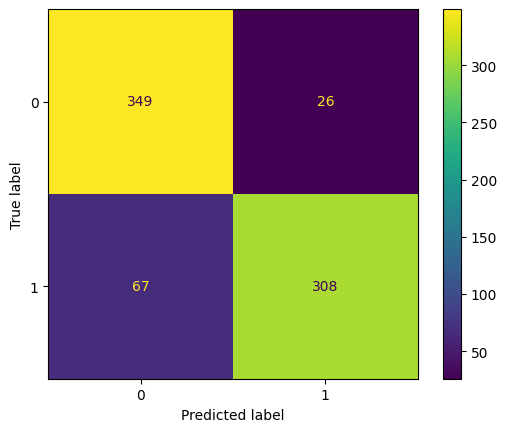

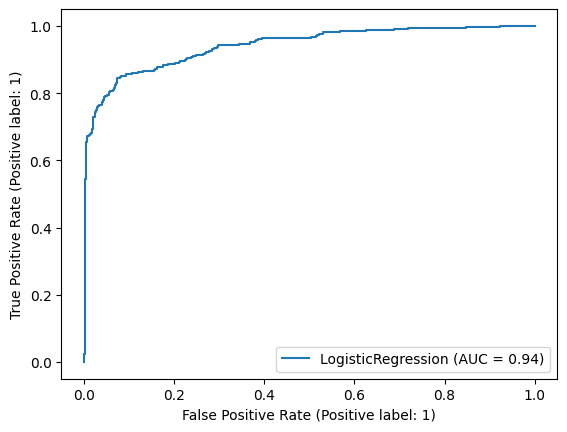

In [128]:
#logistic regression model

model = LogisticRegression()
model.fit(x_train, y_train)

train_score = model.score(x_train, y_train)
test_score = model.score(x_test,y_test)

y_pred = model.predict(x_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

model_results.append([accuracy,precision,recall,test_score])
#how accurate is the model
print("Accuracy:",accuracy)

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",precision)

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",recall)
print("Training score: {:.3f}".format(train_score))
print("Test score: {:.3f}".format(test_score))

#confusion martrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()

#roc curve
RocCurveDisplay.from_estimator(model,x_test,y_test)
plt.show()

Accuracy: 0.884
Precision: 0.941717791411043
Recall: 0.8186666666666667
Training score: 0.893
Test score: 0.884


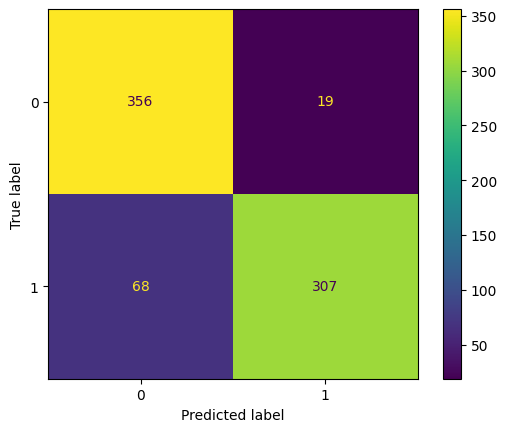

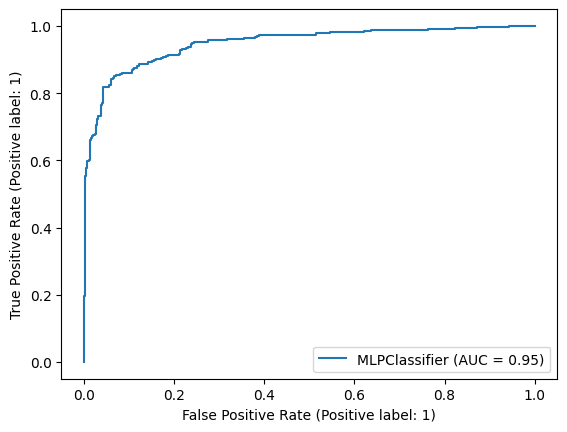

In [129]:
#mlp classifier

model = MLPClassifier(max_iter=2200, alpha=0.0001,hidden_layer_sizes=(100,),learning_rate='constant')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

train_score = model.score(x_train, y_train)
test_score = model.score(x_test, y_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

model_results.append([accuracy,precision,recall,test_score])

#how accurate is the model
print("Accuracy:",accuracy)

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",precision)

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",recall)

print("Training score: {:.3f}".format(train_score))
print("Test score: {:.3f}".format(test_score))


#confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()

#roc curve
RocCurveDisplay.from_estimator(model,x_test,y_test)
plt.show()

Accuracy: 0.8866666666666667
Precision: 0.9447852760736196
Recall: 0.8213333333333334
Training score: 0.893
Test score: 0.887


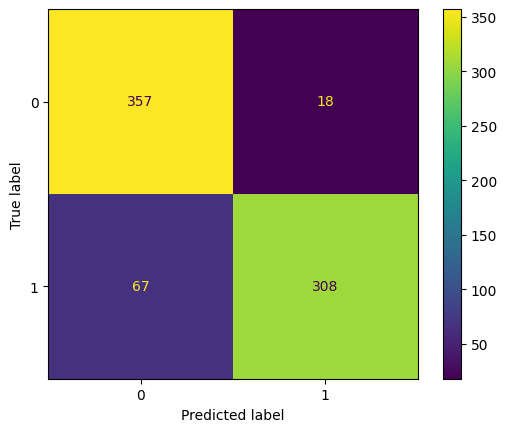

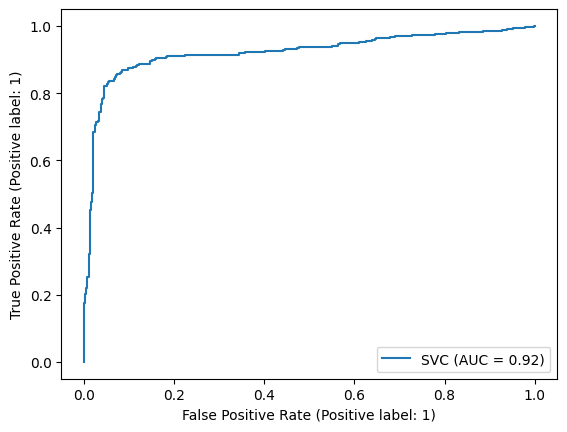

In [130]:
#svm
model = svm.SVC(kernel='rbf', C=11) # Linear Kernel
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

train_score = model.score(x_train, y_train)
test_score = model.score(x_test, y_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

model_results.append([accuracy,precision,recall,test_score])
#how accurate is the model
print("Accuracy:",accuracy)

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",precision)

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",recall)


print("Training score: {:.3f}".format(train_score))
print("Test score: {:.3f}".format(test_score))

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()

#roc curve
RocCurveDisplay.from_estimator(model,x_test,y_test)
plt.show()

Accuracy: 0.888
Precision: 0.944954128440367
Recall: 0.824
Training score: 1.000
Test score: 0.888


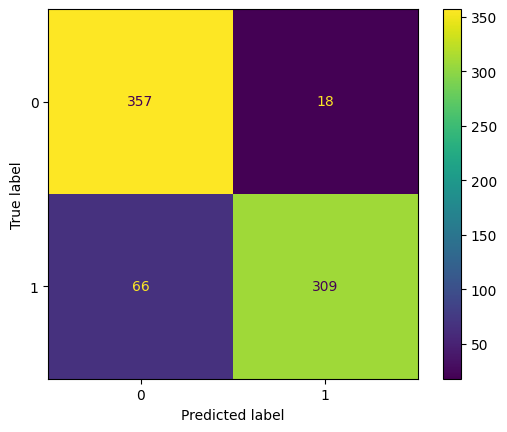

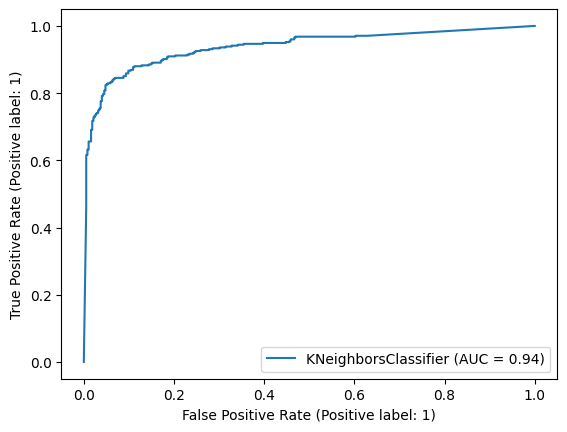

In [131]:
model = KNeighborsClassifier(n_neighbors=14,leaf_size=15,weights='distance')
model.fit(x_train, y_train)

#Predict the response for test dataset
y_pred = model.predict(x_test)

train_score = model.score(x_train, y_train)
test_score = model.score(x_test, y_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

model_results.append([accuracy,precision,recall,test_score])
#how accurate is the model
print("Accuracy:",accuracy)

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",precision)

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",recall)



print("Training score: {:.3f}".format(train_score))
print("Test score: {:.3f}".format(test_score))

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()

#roc curve
RocCurveDisplay.from_estimator(model,x_test,y_test)
plt.show()

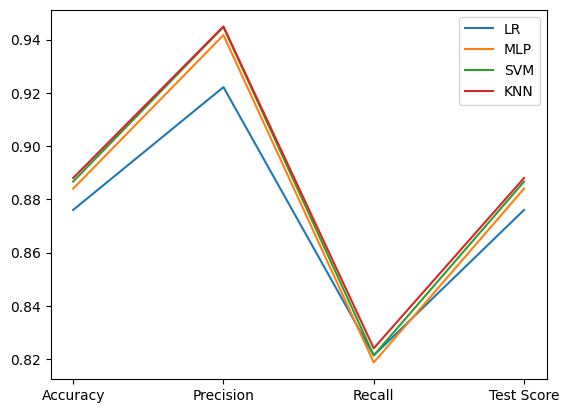

In [132]:
#https://stackoverflow.com/questions/64949449/plotting-line-graph-for-3-variables-in-python
x_axis = ["Accuracy","Precision","Recall","Test Score"]
plt.figure()
for i in range(len(model_names)):
    plt.plot(x_axis, model_results[i], label = model_names[i])

plt.legend()
plt.show()